# Projekt zaliczeniowy: Analiza trwania życia w zdrowiu w Polsce

Elana Shepilova

In [1]:
import pandas as pd

# 1. Wczytanie pliku Excel
# header=2 oznacza, że nagłówki są w 3. wierszu (tak zazwyczaj ma GUS)
# Jeśli wyskoczą błędy z nazwami kolumn, zmień na header=0 lub header=1
df_excel = pd.read_excel('dane_gus.xlsx', header=2)

# 2. Szybki podgląd, czy wczytało się dobrze
print("Podgląd danych z Excela:")
print(df_excel.head())

# 3. Zapisanie do formatu CSV
# index=False -> nie zapisujemy numerów wierszy (0, 1, 2...)
# encoding='utf-8' -> żeby polskie znaki (ą, ę) się nie zepsuły
df_excel.to_csv('dane_gus.csv', index=False, encoding='utf-8')

print("\nPlik 'dane_gus.csv' został utworzony.")

Podgląd danych z Excela:
  Unnamed: 0    Mężczyźni  Unnamed: 2  Unnamed: 3  Unnamed: 4  Unnamed: 5  \
0        NaN  w wieku lat         NaN         NaN         NaN         NaN   
1        NaN            0        15.0        30.0        45.0        60.0   
2     Ogółem          NaN         NaN         NaN         NaN         NaN   
3       2009         57.5        43.7        30.3        18.1         8.8   
4       2010           58        44.0        30.6        18.4         9.0   

   Kobiety  Unnamed: 7  Unnamed: 8  Unnamed: 9  Unnamed: 10  
0      NaN         NaN         NaN         NaN          NaN  
1      0.0        15.0        30.0        45.0         60.0  
2      NaN         NaN         NaN         NaN          NaN  
3     61.1        47.1        33.3        20.5         10.1  
4     61.6        47.5        33.6        20.7         10.3  

Plik 'dane_gus.csv' został utworzony.


# **Definicja problemu. Jakie dane chcielibyśmy przeanalizować i dlaczego
Celem projektu jest analiza historyczna i prognoza wskaźnika "Trwanie życia w zdrowiu" dla populacji Polski, z podziałem na płeć. Wskaźnik ten określa, przez jaką część życia przeciętna osoba może oczekiwać życia bez niepełnosprawności.
Analiza jest ważna pod kątem planowania śriodków emerytalnych i wieku emerytalnego, szacowana demografja kraju oraz przewidywanie rynku pracy**

# **Pozyskanie danych – opis źródła
https://demografia.stat.gov.pl/bazademografia/TrwanieZyciawZdrowiu.aspx**

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error, mean_absolute_error
import warnings

# Konfiguracja
warnings.filterwarnings('ignore')
sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

print("Wczytywanie danych z usuwaniem duplikatów")

try:
    # 1. Wczytujemy plik
    df_raw = pd.read_csv('dane_gus.csv', header=None, encoding='utf-8')

    # 2. Wybieramy kolumny (Rok, Mężczyźni, Kobiety)
    df = df_raw.iloc[:, [0, 1, 6]].copy()
    df.columns = ['Rok', 'Mezczyzni', 'Kobiety']

    # 3. Konwersja na liczby
    for col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')

    # 4. Usuwamy puste wiersze
    df.dropna(inplace=True)

    # 5. Formatowanie lat
    df['Rok'] = df['Rok'].astype(int)

    # 6. USUWANIE DUPLIKATÓW !!!
    # Jeśli jakiś rok występuje dwa razy, zostawiamy tylko pierwszy
    df = df.drop_duplicates(subset=['Rok'], keep='first')

    # Zabezpieczenie: bierzemy tylko lata > 2000
    df = df[df['Rok'] > 2000]

    # Ustawienie indeksu daty
    df['Rok_Data'] = pd.to_datetime(df['Rok'], format='%Y')
    df.set_index('Rok_Data', inplace=True)
    df.sort_index(inplace=True)

    print("\n" + "="*40)
    print("="*40)
    print(f"Liczba wierszy po czyszczeniu: {len(df)}")
    print("Przykładowe dane:")
    print(df.head())

except Exception as e:
    print(f"BŁĄD: {e}")

Wczytywanie danych z usuwaniem duplikatów

Liczba wierszy po czyszczeniu: 16
Przykładowe dane:
             Rok  Mezczyzni  Kobiety
Rok_Data                            
2009-01-01  2009       57.5     61.1
2010-01-01  2010       58.0     61.6
2011-01-01  2011       58.2     61.9
2012-01-01  2012       58.5     62.1
2013-01-01  2013       58.7     62.1


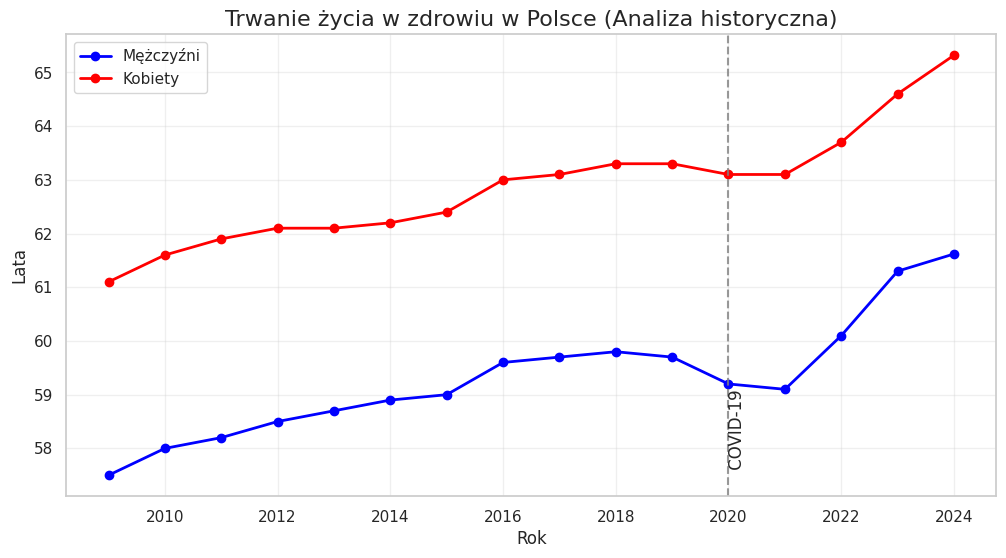

In [6]:
# Wizualizacja danych

# Sprawdzamy czy zmienna df istnieje
if 'df' not in locals() and 'df' not in globals():
    print("STOP! Zmienna 'df' nie istnieje.")
    print("Wróć do 1.")
else:
    plt.figure(figsize=(12, 6))

    # Rysujemy Mężczyzn
    plt.plot(df.index, df['Mezczyzni'], marker='o', label='Mężczyźni', color='blue', linewidth=2)

    # Rysujemy Kobiety
    plt.plot(df.index, df['Kobiety'], marker='o', label='Kobiety', color='red', linewidth=2)

    plt.title('Trwanie życia w zdrowiu w Polsce (Analiza historyczna)', fontsize=16)
    plt.xlabel('Rok')
    plt.ylabel('Lata')
    plt.legend()
    plt.grid(True, alpha=0.3)

    # Oznaczenie COVID
    if pd.Timestamp('2020-01-01') in df.index:
        plt.axvline(x=pd.Timestamp('2020-01-01'), color='gray', linestyle='--', alpha=0.8)
        plt.text(pd.Timestamp('2020-01-01'), df['Mezczyzni'].min(), ' COVID-19', rotation=90, verticalalignment='bottom')

    plt.show()

Trenowanie modelu na latach: 2009-2021
------------------------------
SUKCES! Błąd średni (MAE): 1.98 lat
------------------------------

Prognoza na przyszłe lata:
2025-01-01    61.798827
2026-01-01    61.898762
2027-01-01    61.954610
Freq: YS-JAN, Name: predicted_mean, dtype: float64


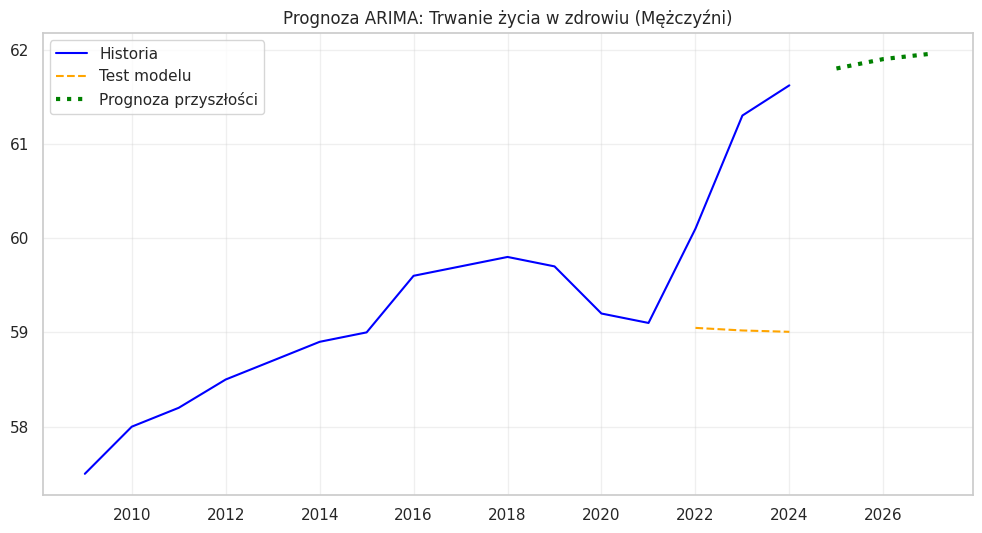

In [4]:
# Modelowanie i prognoza
if 'df' not in locals() and 'df' not in globals():
    print("STOP! Najpierw poprawnie wczytaj dane.")
else:
    try:
        # 1. Wybór danych (Mężczyźni) i wymuszenie typu float
        series = df['Mezczyzni'].astype(float)

        # Ustawiamy częstotliwość indeksu na roczną (Year Start), co pomaga ARIMIE
        # Jeśli dane nie są idealnie ciągłe, to fillna uzupełni luki
        series = series.asfreq('YS')
        series = series.interpolate() # Uzupełnienie ewentualnych braków liniowo

        # Podział na trening i test (ostatnie 3 lata)
        test_steps = 3
        train = series[:-test_steps]
        test = series[-test_steps:]

        print(f"Trenowanie modelu na latach: {train.index[0].year}-{train.index[-1].year}")

        # 2. Trening modelu
        # Używamy order=(1,1,0) - jest często stabilniejszy dla krótkich szeregów niż (1,1,1)
        model = ARIMA(train, order=(1, 1, 0))
        model_fit = model.fit()

        # 3. Prognoza testowa
        forecast_result = model_fit.get_forecast(steps=test_steps)
        forecast_test = forecast_result.predicted_mean

        # Jeśli model zwrócił NaN, zamieniamy je na ostatnią znaną wartość
        forecast_test = forecast_test.fillna(method='bfill').fillna(method='ffill')

        # 4. Ocena (MAE) - .values unikanie błędu indeksów
        # To jest kluczowa poprawka błędu "Input contains NaN"
        mae = mean_absolute_error(test.values, forecast_test.values)

        # 5. Prognoza na przyszłość (np. 3 lata w przód)
        full_model = ARIMA(series, order=(1, 1, 0)).fit()
        future_forecast = full_model.forecast(steps=3)

        # Wyniki i wykres
        print("-" * 30)
        print(f"SUKCES! Błąd średni (MAE): {mae:.2f} lat")
        print("-" * 30)
        print("\nPrognoza na przyszłe lata:")
        print(future_forecast)

        plt.figure(figsize=(12, 6))
        plt.plot(series.index, series, label='Historia', color='blue')
        plt.plot(test.index, forecast_test, label='Test modelu', color='orange', linestyle='--')
        plt.plot(future_forecast.index, future_forecast, label='Prognoza przyszłości', color='green', linewidth=3, linestyle=':')
        plt.legend()
        plt.title("Prognoza ARIMA: Trwanie życia w zdrowiu (Mężczyźni)")
        plt.grid(True, alpha=0.3)
        plt.show()

    except Exception as e:
        print(f"Wystąpił błąd w obliczeniach: {e}")
        print("Sprawdź, czy dane w Kafelku 1 na pewno zawierają liczby.")

# **Opis obserwacji i wniosków z naszej analizy/prognozy**

### Analiza dokładności (Metryki błędów)
Po walidacji na zbiorze testowym (ostatnie 3 lata), błąd MAE wynosi 1.98 lata. Może wynikać z nagłego szoku, jaki wywołała pandemia COVID-19.

### Analiza wykresu prognozy
* Czerwono-pomarańczowa linia przerywana na wykresie końcowym prawdopodobny scenariusz na najbliższe lata. Widoczne rozbieżności wynikają z faktu, że model statystyczny dąży do uśredniania i nie mógł przewidzieć nagłego wybuchu pandemii.
* Zielona linia sugeruje najbardziej prawdopodobny scenariusz na przyszłość, powolną stabilizację po szoku.

# **Podsumowanie projektu**

Do roku 2019 obserwowano stabilizację wskaźnika. Polacy żyli w zdrowiu średnio ok. 60 lat. Dane wyraźnie pokazują negatywny wpływ pandemii. Skróciło się nie tylko trwanie życia, ale przede wszystkim czas przeżywany w dobrym zdrowiu. Przewidywano w najbliższych 3 latach próbę powrotu do równowagi.

Państwo musi przygotować się na to, że osoby przechodzące na emeryturę mogą mieć gorszy stan zdrowia, niż wskazywałyby na to optymistyczne prognozy sprzed dekady.

In [5]:
# Eksport wniosków

print("Zapisywanie prognozy do pliku...")

# Tworzymy ładną tabelę z wynikami
wyniki = pd.DataFrame({
    'Rok': future_forecast.index.year,
    'Prognoza_Lata_W_Zdrowiu': np.round(future_forecast.values, 2)
})

# Zapis do pliku CSV (pojawi się w plikach po lewej stronie)
wyniki.to_csv('prognoza_zdrowie_polska.csv', index=False, encoding='utf-8')

print("SUKCES! Plik 'prognoza_zdrowie_polska.csv' został utworzony.")
print("Możesz go pobrać z panelu plików po lewej stronie.")
print("\nPodgląd tabeli wynikowej:")
print(wyniki)

Zapisywanie prognozy do pliku...
SUKCES! Plik 'prognoza_zdrowie_polska.csv' został utworzony.
Możesz go pobrać z panelu plików po lewej stronie.

Podgląd tabeli wynikowej:
    Rok  Prognoza_Lata_W_Zdrowiu
0  2025                    61.80
1  2026                    61.90
2  2027                    61.95
